In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
df = pd.read_csv('example_data_1_PHYS_433_533.csv')
print(df)

      f_res  max_power_dBm
0      3000          -54.0
1      3002          -54.1
2      3004          -54.0
3      3006          -53.9
4      3008          -53.8
...     ...            ...
996    4992          -63.8
997    4994          -63.3
998    4996          -63.3
999    4998          -63.8
1000   5000          -64.2

[1001 rows x 2 columns]


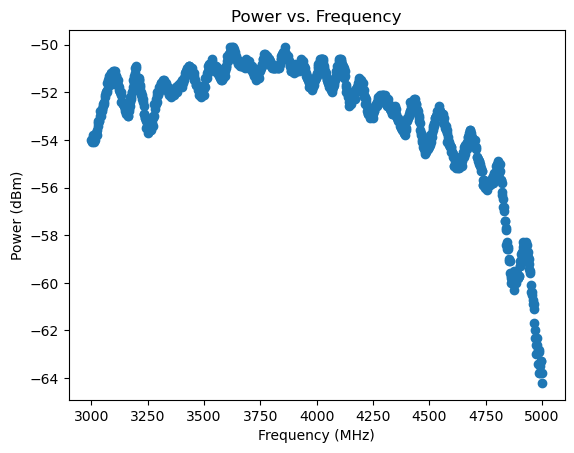

In [3]:
frequency = df['f_res']
power_dBm = df['max_power_dBm']

plt.title("Power vs. Frequency")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Power (dBm)")

plt.scatter(frequency, power_dBm)
plt.show()

In [6]:
power_mW = 10 ** (np.array(power_dBm) / 10)
print(power_mW[:5])

[3.98107171e-06 3.89045145e-06 3.98107171e-06 4.07380278e-06
 4.16869383e-06]


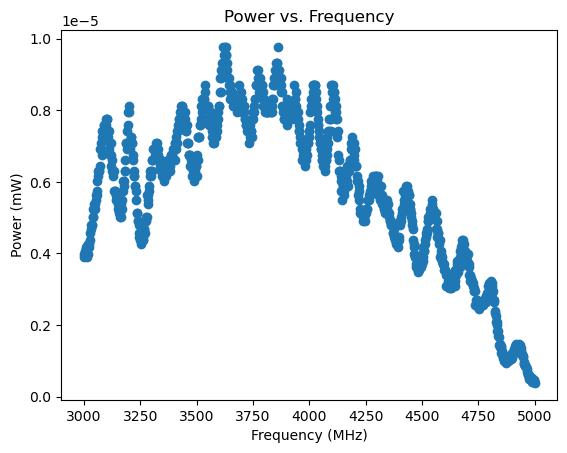

In [7]:
plt.title("Power vs. Frequency")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Power (mW)")
plt.scatter(frequency, power_mW)
plt.show()

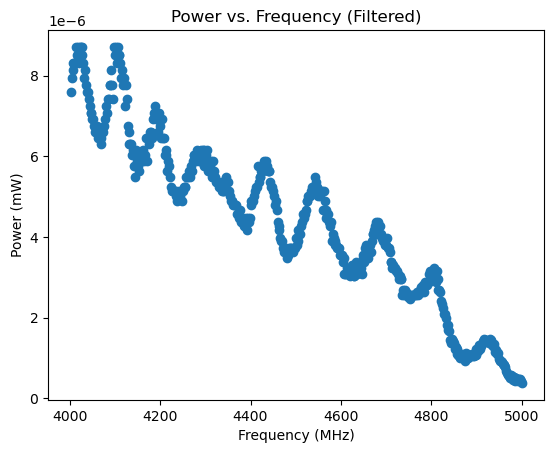

In [8]:
mask = frequency > 4000
frequency_filtered = frequency[mask]
power_mW_filtered = power_mW[mask]

plt.title("Power vs. Frequency (Filtered)")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Power (mW)")
plt.scatter(frequency_filtered, power_mW_filtered)
plt.show()

[-6.93853653e-09  3.55731201e-05]
[[ 9.43181768e-21 -4.24526116e-17]
 [-4.24526116e-17  1.91865187e-13]]


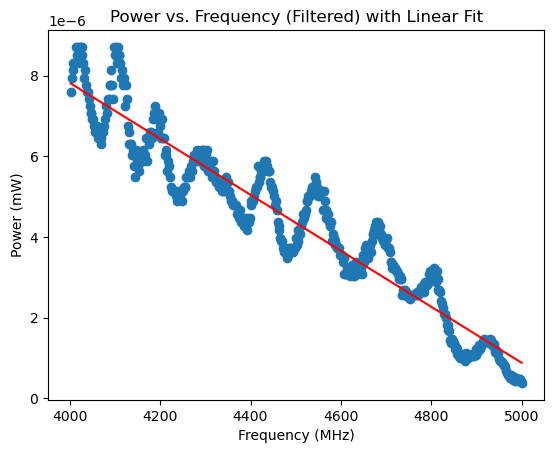

In [11]:
def linear_fit(x, m, b):
    return m * x + b

popt, pcov = curve_fit(linear_fit, frequency_filtered, power_mW_filtered, p0=[-1, 4e-5])
print(popt)
print(pcov)

plt.title("Power vs. Frequency (Filtered) with Linear Fit")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Power (mW)")
plt.scatter(frequency_filtered, power_mW_filtered)
plt.plot(frequency_filtered, linear_fit(frequency_filtered, popt[0], popt[1]), color='red')
         
plt.show()